In [48]:
#setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv('Titanic-Dataset.csv').set_index('PassengerId')
print(df.head(10))
#print(df.describe())
df.info()
#print(df.shape)

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   
6                   0       3   
7                   0       1   
8                   0       3   
9                   1       3   
10                  1       2   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   
6                                          

In [49]:
#data cleaning
df.Age = df.Age.fillna(df.Age.mean())#Fill age
df  = df.dropna(subset = ['Embarked'])#Remove NaN
df = df.drop('Cabin' ,axis = 'columns')#Remove column Cabin(too many null value)
df.Survived = df.Survived.astype(bool)#Resructure
print(df.head())
df.info()

             Survived  Pclass  \
PassengerId                     
1               False       3   
2                True       1   
3                True       3   
4                True       1   
5               False       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Embarked  
PassengerId                                                    
1                1      0         A/5 21171   7.2500        S  
2              

In [50]:
print('Number of passengers survived:')
pass_survived = df.Survived.loc[df.Survived].count()
print(pass_survived)

Number of passengers survived:
340


In [51]:
print('Survival rate by gender:')
gender_survival_rate = (df.loc[df.Survived].groupby('Sex').Survived.count() / df.groupby('Sex').Survived.count()).sort_index(ascending = False)
print(gender_survival_rate)

Survival rate by gender:
Sex
male      0.188908
female    0.740385
Name: Survived, dtype: float64


In [52]:


print('Survival rate by Pclass:')
Pclass_survival_rate = df.loc[df.Survived].groupby('Pclass').Survived.count() / df.groupby('Pclass').Survived.count()
print(Pclass_survival_rate)

Survival rate by Pclass:
Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [53]:
print('Average age stats:')
average_age = df.groupby('Survived').Age.mean().sort_index(ascending = False)
print(average_age)

Average age stats:
Survived
True     28.4236
False    30.4151
Name: Age, dtype: float64


In [54]:
print('Passenger that paid highest fare:')
highest_fare = df.loc[df.Fare == df.Fare.max(),['Name','Fare','Pclass']]
print(highest_fare)

Passenger that paid highest fare:
                                           Name      Fare  Pclass
PassengerId                                                      
259                            Ward, Miss. Anna  512.3292       1
680          Cardeza, Mr. Thomas Drake Martinez  512.3292       1
738                      Lesurer, Mr. Gustave J  512.3292       1


In [55]:
# Add new colum Familysize
df['FamilySize'] = df.SibSp + df.Parch + 1
print(df.head())

             Survived  Pclass  \
PassengerId                     
1               False       3   
2                True       1   
3                True       3   
4                True       1   
5               False       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Embarked  FamilySize  
PassengerId                                                                
1                1      0         A/5 21171   7.2500   

In [56]:
# Add new column IsAlone
def IsAlone(row):
  if int(row) >1:
    return False
  else:
    return True
df['IsAlone'] = df.FamilySize.apply(IsAlone)
print(df.head())

             Survived  Pclass  \
PassengerId                     
1               False       3   
2                True       1   
3                True       3   
4                True       1   
5               False       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Embarked  FamilySize  \
PassengerId                                                                 
1                1      0         A/5 21171   7.2500 

In [57]:
print('Embarked per port:')
embarked = df.groupby('Embarked').size()
print(embarked)

Embarked per port:
Embarked
C    168
Q     77
S    644
dtype: int64


In [58]:
print('Average fare by embarked port:')
average_fare_port = df.groupby('Embarked').Fare.mean().round(2)
print(average_fare_port)

Average fare by embarked port:
Embarked
C    59.95
Q    13.28
S    27.08
Name: Fare, dtype: float64


In [59]:
def extract_title(row):
  row = row.lower()
  if 'miss.' in row:
    return 'Miss'
  elif 'mrs.' in row:
    return 'Mrs'
  elif 'mr.' in row:
    return 'Mr'
  else:
    return 'Others'
title_count = df.Name.apply(extract_title).value_counts()
print('Number of titles:')
print(title_count)

Number of titles:
Name
Mr        517
Miss      181
Mrs       124
Others     67
Name: count, dtype: int64


In [60]:
#Age stats
age_np = np.array(df.Age)
print(age_np.mean())
print(age_np.std())
print(age_np.min())
print(age_np.max())

29.65344637067425
12.961070462649968
0.42
80.0


In [61]:
#Normalised Fare
fare_np = np.array(df.Fare)
fare_Norm =(fare_np - fare_np.mean()) / fare_np.std()
print(fare_Norm.mean())
print(fare_Norm.std())

1.3987061727561027e-16
1.0


In [62]:
#Comparing with random age
random_age = np.random.rand(age_np.size)
random_age = random_age * 80
print(random_age.mean())
print(random_age.std())
print(random_age.min())
print(random_age.max())

40.184356747216206
23.38496674234961
0.04021094612936871
79.96437361120331


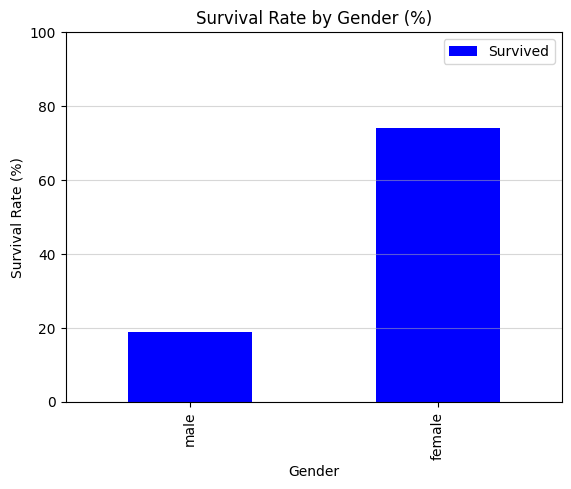

In [76]:
#Plot
survival_rate_data = pd.DataFrame(gender_survival_rate)*100
survival_rate_data.plot(kind='bar')
plt.title('Survival Rate by Gender (%)')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Gender')
plt.ylim(0, 100)          # Makes y-axis from 0 to 100 for clarity
plt.grid(axis='y', alpha=0.5)  # Light grid helps read values
plt.show()

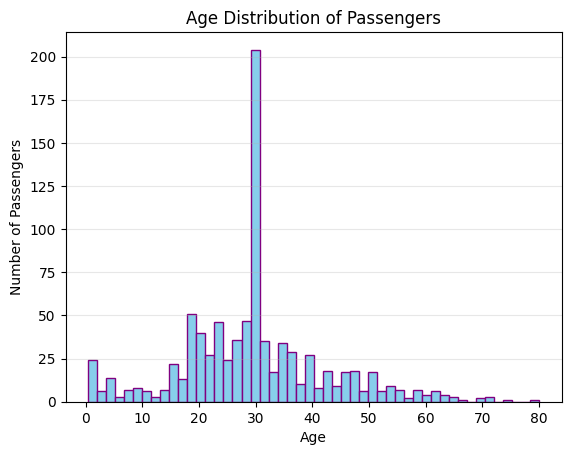

In [81]:
df['Age'].plot(kind='hist',
               bins=50,           # 20 bars — good balance
               color='skyblue',
               edgecolor = 'purple')

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.grid(axis='y', alpha=0.3)
plt.show()

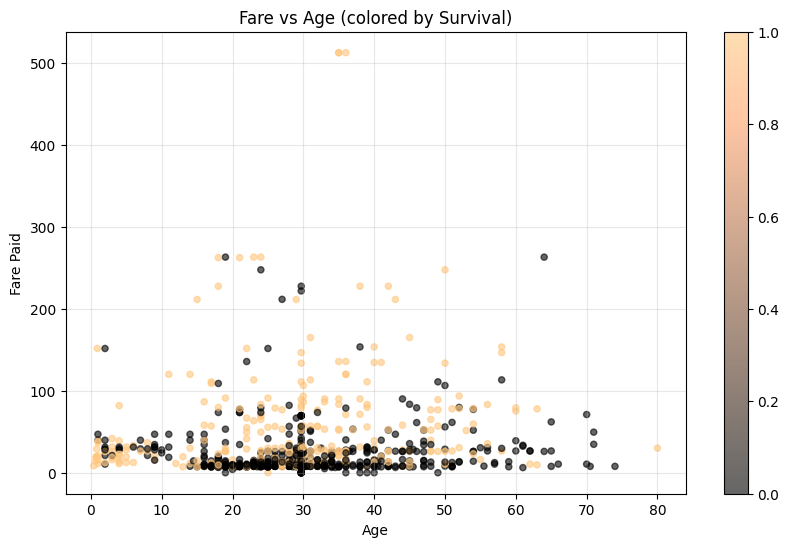

In [88]:
df.plot(kind='scatter',
        x='Age',
        y='Fare',
        c = df['Survived'],# Color by Survived column (0/1)
        colormap='copper',       # Nice color map: yellow=1 (survived), purple=0
        alpha=0.6,                # Slight transparency so overlapping points visible
        figsize=(10, 6))          # Bigger size

plt.title('Fare vs Age (colored by Survival)')
plt.xlabel('Age')
plt.ylabel('Fare Paid')
plt.grid(True, alpha=0.3)
plt.show()